# Векторизация текста


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")

Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [4]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")

Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация — процесс приведения слова к его нормальной форме (лемме):
- для существительных — именительный падеж, единственное число;
- для прилагательных — именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий — глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [5]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [6]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [7]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [8]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [9]:
def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])

После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [10]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")

Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [11]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])

Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [12]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")

Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  way: 1
  plotter: 1
  would: 1
  michael: 1
  standard: 1
  response: 1
  please: 1
  thanks: 1
  utility: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [13]:
def preprocess_no_lemstem(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

def preprocess_only_lemma(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

X_train_no_lemstem = [preprocess_no_lemstem(text) for text in newsgroups_train.data[:1000]]
X_train_only_lemma = [preprocess_only_lemma(text) for text in newsgroups_train.data[:1000]]

# Создаем BoW без ограничения на размер словаря (убираем max_features)
bow_no_lemstem = CountVectorizer(min_df=2, max_df=0.95)
bow_only_lemma = CountVectorizer(min_df=2, max_df=0.95)

X_train_bow_no_lemstem = bow_no_lemstem.fit_transform(X_train_no_lemstem)
X_train_bow_only_lemma = bow_only_lemma.fit_transform(X_train_only_lemma)

print(f"Размер словаря без лемматизации и стемминга: {len(bow_no_lemstem.vocabulary_)}")
print(f"Размер словаря с лемматизацией: {len(bow_only_lemma.vocabulary_)}")

def print_top_words(vectorizer, data, title):
    word_counts = data.sum(axis=0).A1
    word_names = vectorizer.get_feature_names_out()
    word_freq = list(zip(word_names, word_counts))
    word_freq.sort(key=lambda x: x[1], reverse=True)
    print(f"\n{title}:")
    for word, count in word_freq[:20]:
        print(f"  {word}: {count}")

print_top_words(bow_no_lemstem, X_train_bow_no_lemstem, "Топ-20 слов без лемматизации")
print_top_words(bow_only_lemma, X_train_bow_only_lemma, "Топ-20 слов с лемматизацией")

Размер словаря без лемматизации и стемминга: 7392
Размер словаря с лемматизацией: 6599

Топ-20 слов без лемматизации:
  would: 676
  one: 672
  god: 655
  people: 476
  dont: 453
  also: 417
  know: 369
  think: 360
  image: 353
  like: 341
  time: 332
  good: 310
  may: 303
  many: 297
  get: 288
  jesus: 274
  even: 267
  say: 254
  much: 253
  use: 253

Топ-20 слов с лемматизацией:
  god: 780
  one: 735
  would: 676
  image: 489
  people: 486
  dont: 453
  also: 417
  know: 402
  time: 387
  think: 370
  like: 343
  say: 343
  get: 317
  good: 312
  thing: 309
  may: 303
  many: 297
  make: 281
  file: 278
  jesus: 278


Отсутствие лемматизации ведет к раздуванию словаря (разные формы считаются разными словами) и размыванию частот (одно и то же слово в разных формах имеет меньший вес по отдельности). Лемматизация делает модель более устойчивой к морфологическим вариациям.

### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")

Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  hail: IDF = 6.810
  academic: IDF = 6.810
  godhead: IDF = 6.810
  abc: IDF = 6.810
  god truth: IDF = 6.810
  hath: IDF = 6.810
  xloadimage: IDF = 6.810
  acidic: IDF = 6.810
  serial port: IDF = 6.810
  septuagint: IDF = 6.810
  worshipping: IDF = 6.810
  worldview: IDF = 6.810
  hernia: IDF = 6.810
  hicolor: IDF = 6.810
  cause effect: IDF = 6.810
  catholic theology: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  showcase: IDF = 6.810
  silicon graphic: IDF = 6.810


In [15]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]

In [16]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

Сравнение настроек TF-IDF

Standard (IDF=True, norm=l2):
  Форма: (1000, 5000)
  Разреженность: 1.19%
  Средний TF-IDF: 0.0011
  Стд TF-IDF: 0.0139

No IDF (use_idf=False):
  Форма: (1000, 5000)
  Разреженность: 1.19%
  Средний TF-IDF: 0.0011
  Стд TF-IDF: 0.0139

Sublinear TF (sublinear_tf=True):
  Форма: (1000, 5000)
  Разреженность: 1.19%
  Средний TF-IDF: 0.0012
  Стд TF-IDF: 0.0139

No Norm (norm=None):
  Форма: (1000, 5000)
  Разреженность: 1.19%
  Средний TF-IDF: 0.0859
  Стд TF-IDF: 1.4609


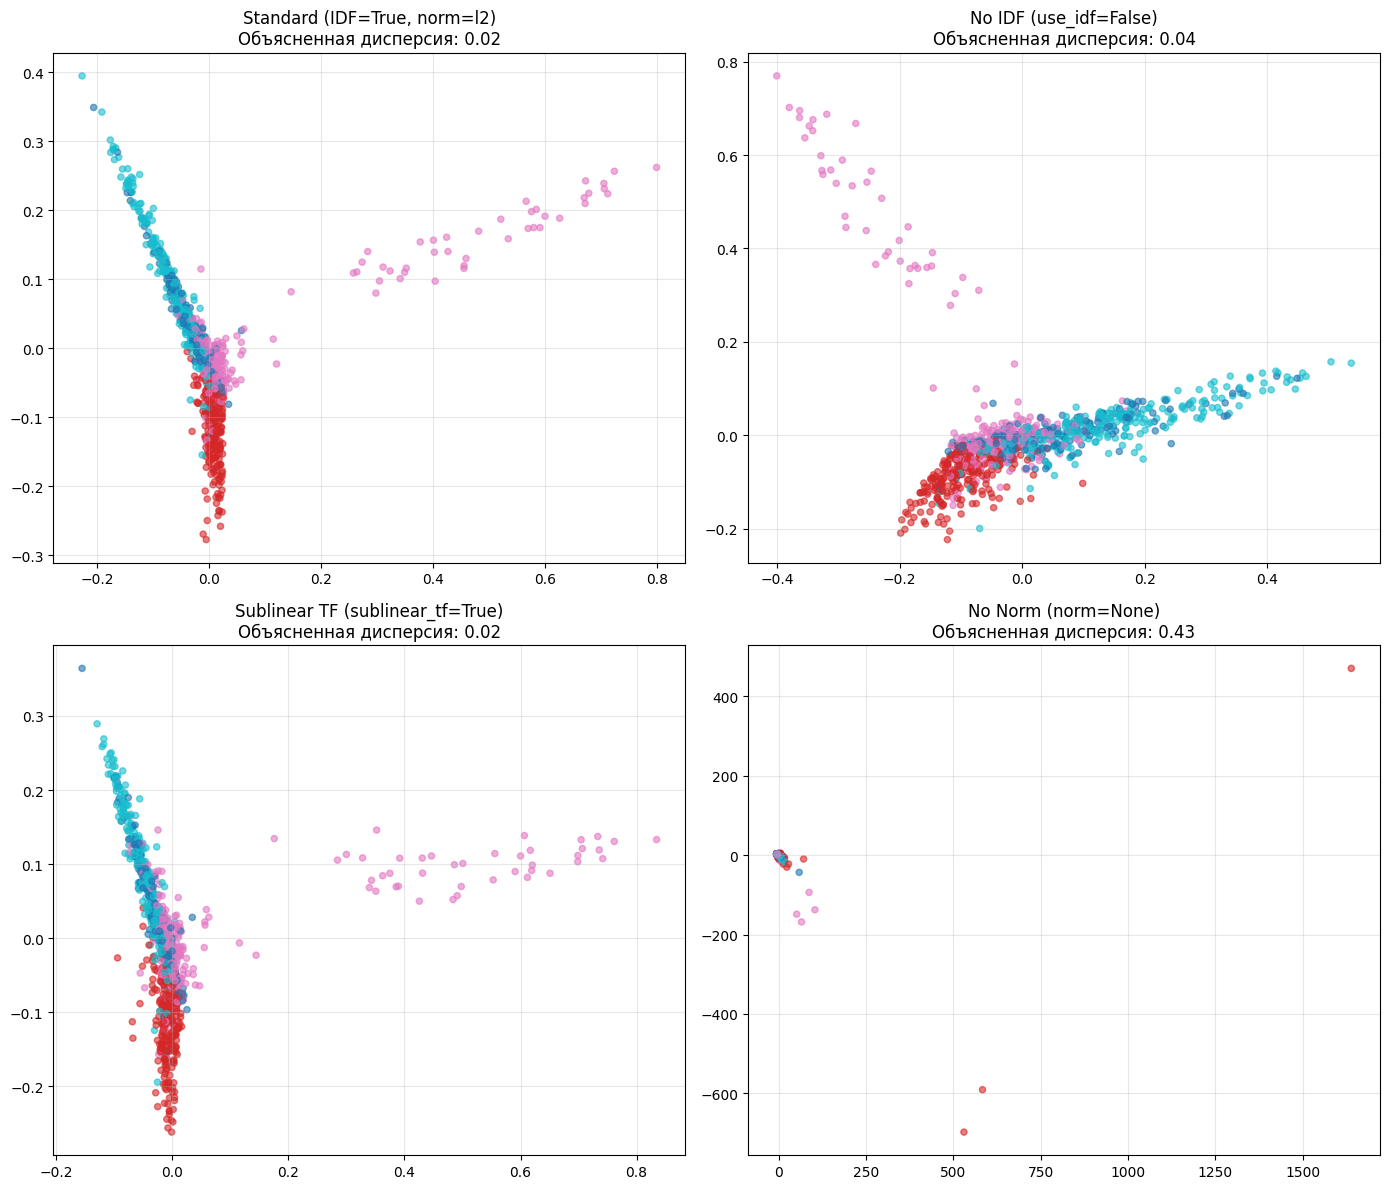

Топ-10 слов (по среднему значению TF-IDF)

Standard (IDF=True, norm=l2):
  god: 0.0254
  would: 0.0254
  one: 0.0225
  know: 0.0195
  dont: 0.0182
  people: 0.0180
  think: 0.0167
  like: 0.0148
  time: 0.0144
  good: 0.0137

No IDF (use_idf=False):
  would: 0.0525
  one: 0.0465
  god: 0.0405
  know: 0.0359
  dont: 0.0341
  people: 0.0325
  think: 0.0287
  like: 0.0267
  time: 0.0247
  good: 0.0227

Sublinear TF (sublinear_tf=True):
  would: 0.0240
  one: 0.0218
  know: 0.0200
  god: 0.0193
  dont: 0.0186
  people: 0.0177
  think: 0.0167
  like: 0.0158
  time: 0.0147
  anyone: 0.0144

No Norm (norm=None):
  god: 2.0844
  image: 1.8903
  one: 1.5778
  would: 1.4261
  people: 1.1903
  jpeg: 1.1829
  dont: 1.0743
  also: 1.0702
  file: 1.0216
  time: 1.0161


In [17]:
X_train_proc = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_proc = [preprocess_text(text) for text in newsgroups_test.data[:500]]

configs = {
    'Standard (IDF=True, norm=l2)': 
        TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95),
    'No IDF (use_idf=False)': 
        TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, use_idf=False),
    'Sublinear TF (sublinear_tf=True)': 
        TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, sublinear_tf=True),
    'No Norm (norm=None)': 
        TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, norm=None),
}

print("Сравнение настроек TF-IDF")

results = {}
for name, vectorizer in configs.items():
    X_tfidf = vectorizer.fit_transform(X_train_proc)
    X_test_tfidf = vectorizer.transform(X_test_proc)
    
    X_dense = X_tfidf.toarray()
    train_mean = X_dense.mean()
    train_std = X_dense.std()
    sparsity = (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100
    
    print(f"\n{name}:")
    print(f"  Форма: {X_tfidf.shape}")
    print(f"  Разреженность: {sparsity:.2f}%")
    print(f"  Средний TF-IDF: {train_mean:.4f}")
    print(f"  Стд TF-IDF: {train_std:.4f}")
    
    results[name] = {'X_train': X_tfidf, 'vectorizer': vectorizer}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, data) in enumerate(results.items()):
    X = data['X_train'].toarray()
    y = newsgroups_train.target[:1000]
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    ax = axes[idx]
    ax.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', alpha=0.6, s=20)
    ax.set_title(f'{name}\nОбъясненная дисперсия: {pca.explained_variance_ratio_.sum():.2f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Топ-10 слов (по среднему значению TF-IDF)")

for name, data in results.items():
    vectorizer = data['vectorizer']
    X = data['X_train']
    
    mean_scores = np.array(X.mean(axis=0)).flatten()
    top_indices = mean_scores.argsort()[-10:][::-1]
    feature_names = vectorizer.get_feature_names_out()
    
    print(f"\n{name}:")
    for idx in top_indices:
        print(f"  {feature_names[idx]}: {mean_scores[idx]:.4f}")

##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) — плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения — максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [ ]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'molecular', 'visualization', 'idl', 'silicon']
  medical: ['newsletter', 'april', 'hicnet', 'journal', 'page', 'volume']
  god: ['eternal', 'fear', 'gift', 'satan', 'sinner', 'soul']
  cat: ['meal', 'tolerate', 'ingredient', 'upset', 'cook', 'seemed']
  cup: ['iraqi', 'injury', 'wine', 'bread', 'bomb', 'unlike']


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход — список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [19]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.015955,-0.002551,0.000693,-0.089028,0.033274,-0.011552,-0.035462,0.021348,0.031082,0.029551,...,0.034646,0.049684,0.073116,-0.024089,0.090142,0.024177,0.079777,0.047554,0.017309,-0.050663
1,-0.214760,-0.469035,-0.158827,-0.362426,0.174923,-0.100774,-0.209658,-0.144653,0.063711,0.372568,...,-0.095123,-0.083268,0.401674,0.068659,0.480990,0.215994,0.458500,0.468015,0.311402,-0.377222
2,-0.324710,-0.804833,-0.245149,-0.573639,0.273206,-0.134189,-0.307093,-0.229635,0.033437,0.548640,...,-0.217928,-0.161531,0.616088,0.010689,0.753220,0.354435,0.788328,0.803950,0.535128,-0.648317
3,-0.047365,-0.180641,-0.063501,-0.115000,0.013166,-0.050376,-0.055603,-0.061385,-0.003233,0.084737,...,-0.066334,-0.055064,0.120177,0.017913,0.124135,0.079628,0.143066,0.133395,0.109077,-0.107643
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [ ]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)

In [ ]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])

Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.9126
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.486332


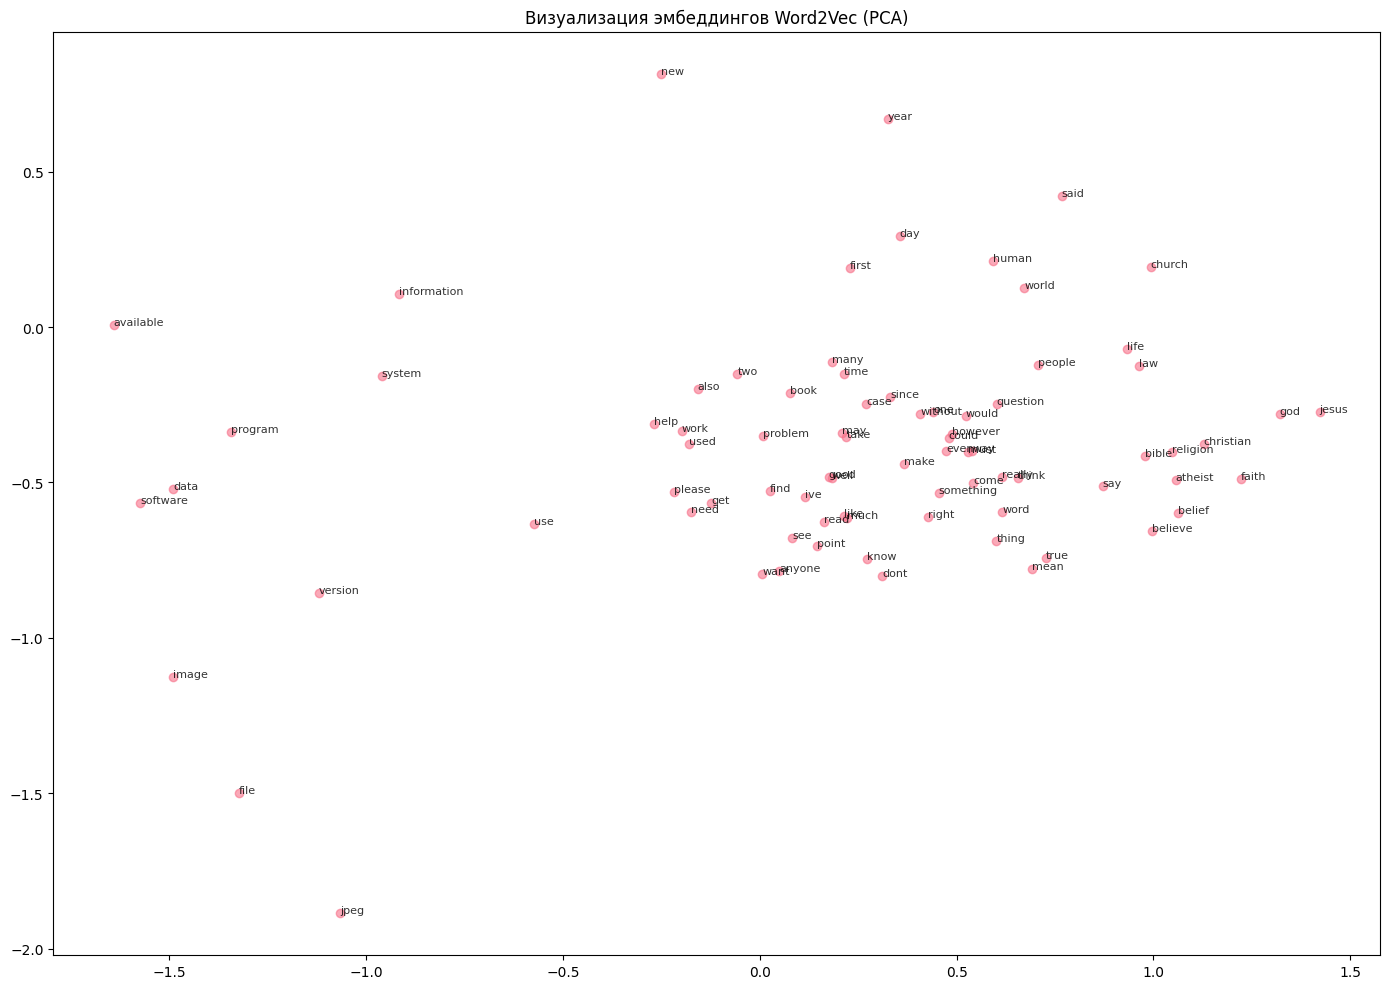

In [ ]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()

PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

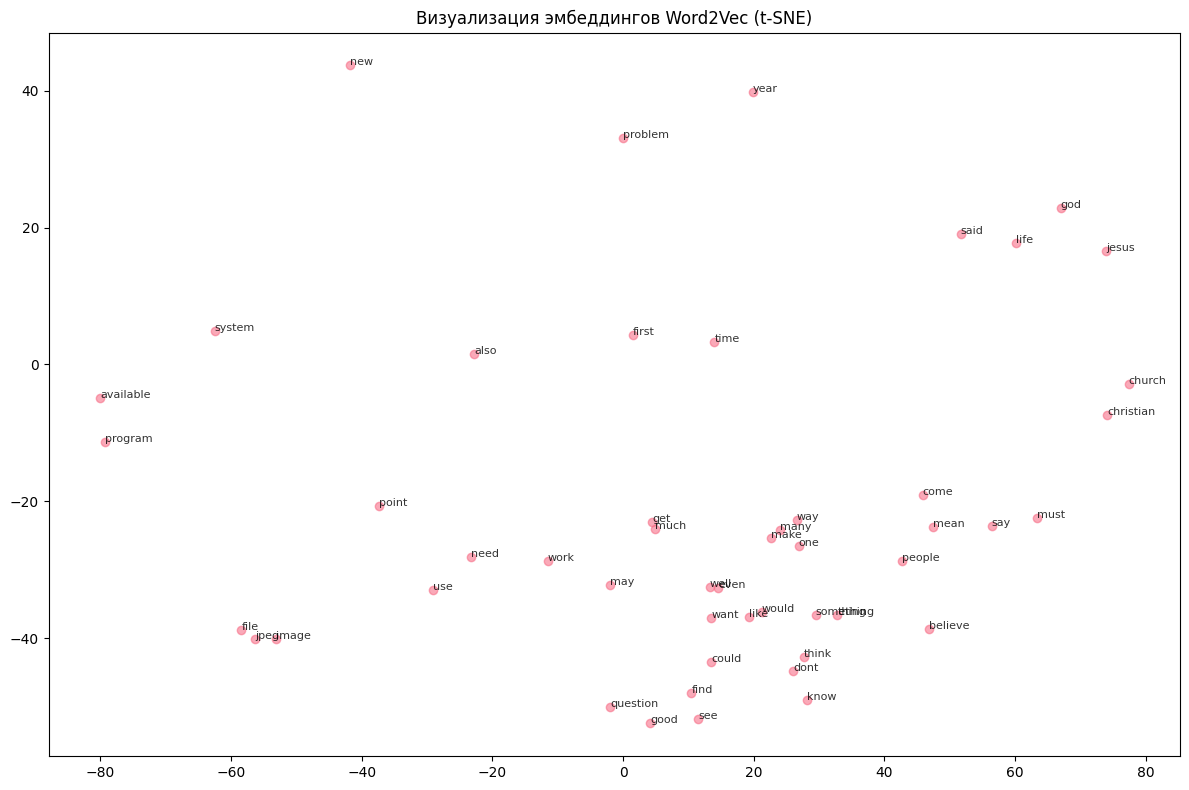

In [24]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15, max_iter=1000)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()

In [ ]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):\n")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()

Ближайшие соседи (Word2Vec):

COMPUTER:
  graphic: 0.0965
  modeling: 0.1080
  molecular: 0.1102
  visualization: 0.1215
  idl: 0.1217
  silicon: 0.1227
  project: 0.1294
  management: 0.1311

MEDICAL:
  newsletter: 0.0734
  april: 0.0804
  hicnet: 0.0846
  journal: 0.1015
  page: 0.1114
  volume: 0.1281
  american: 0.1709
  vol: 0.1723

GOD:
  eternal: 0.1463
  fear: 0.1539
  gift: 0.1594
  satan: 0.1642
  sinner: 0.1654
  soul: 0.1690
  justice: 0.1718
  bear: 0.1721

SCIENCE:
  collection: 0.1714
  empirical: 0.1812
  basic: 0.2015
  theory: 0.2305
  methodology: 0.2357
  scientific: 0.2419
  competing: 0.2421
  research: 0.2430



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [26]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** — последовательность из $n$ подряд идущих слов (униграмма — одно слово, биграмма — пара, триграмма — тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [27]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [28]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


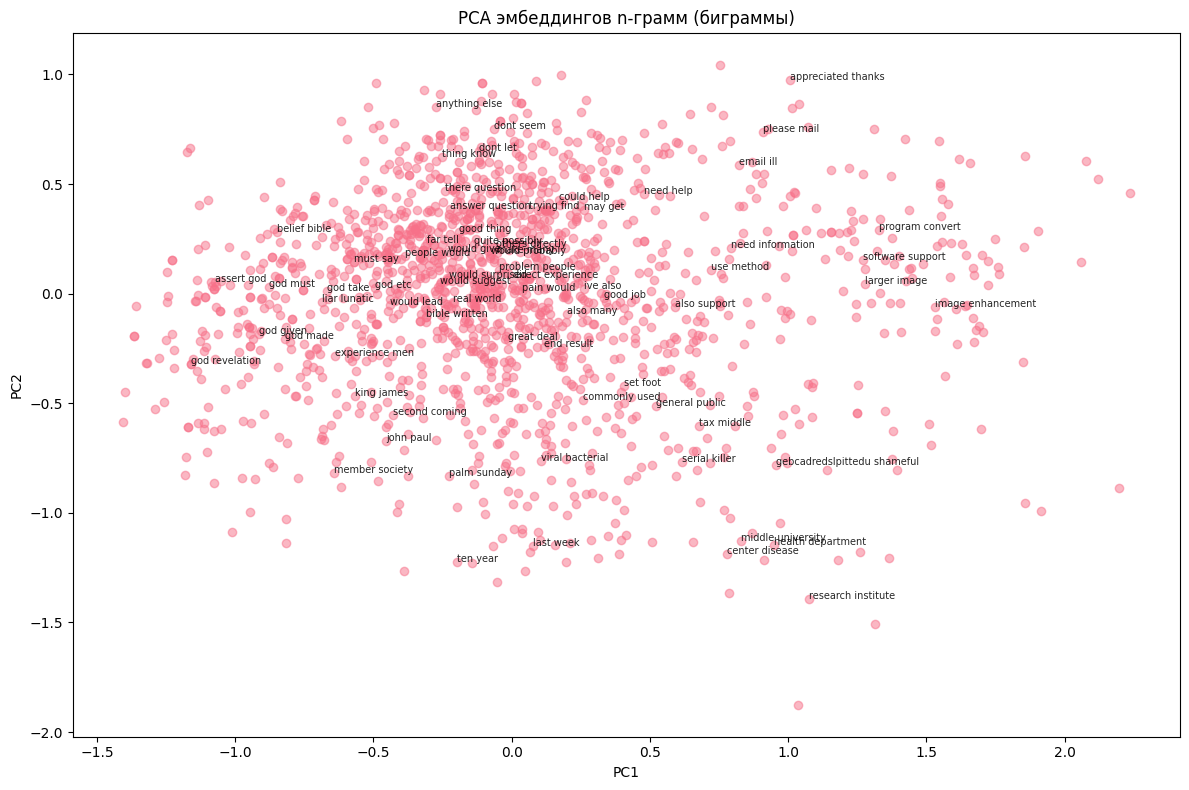

In [29]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

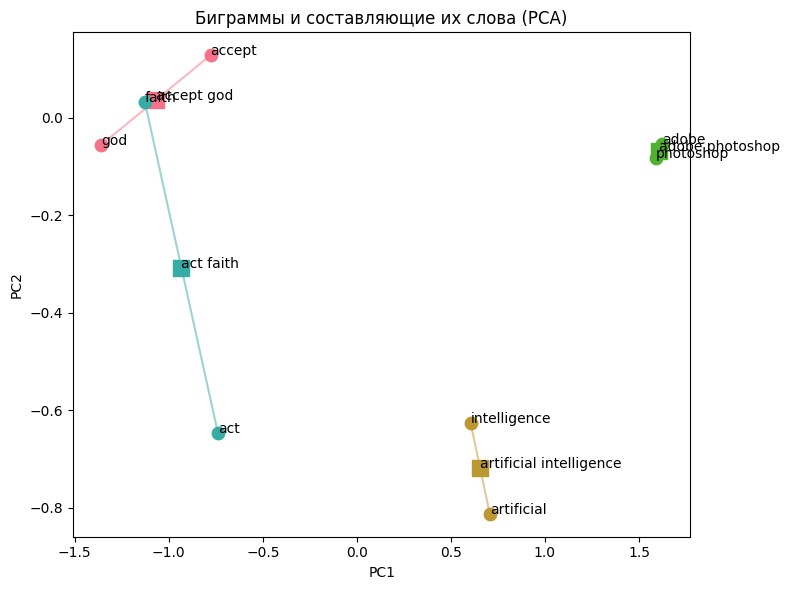

In [30]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [31]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]

Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.505


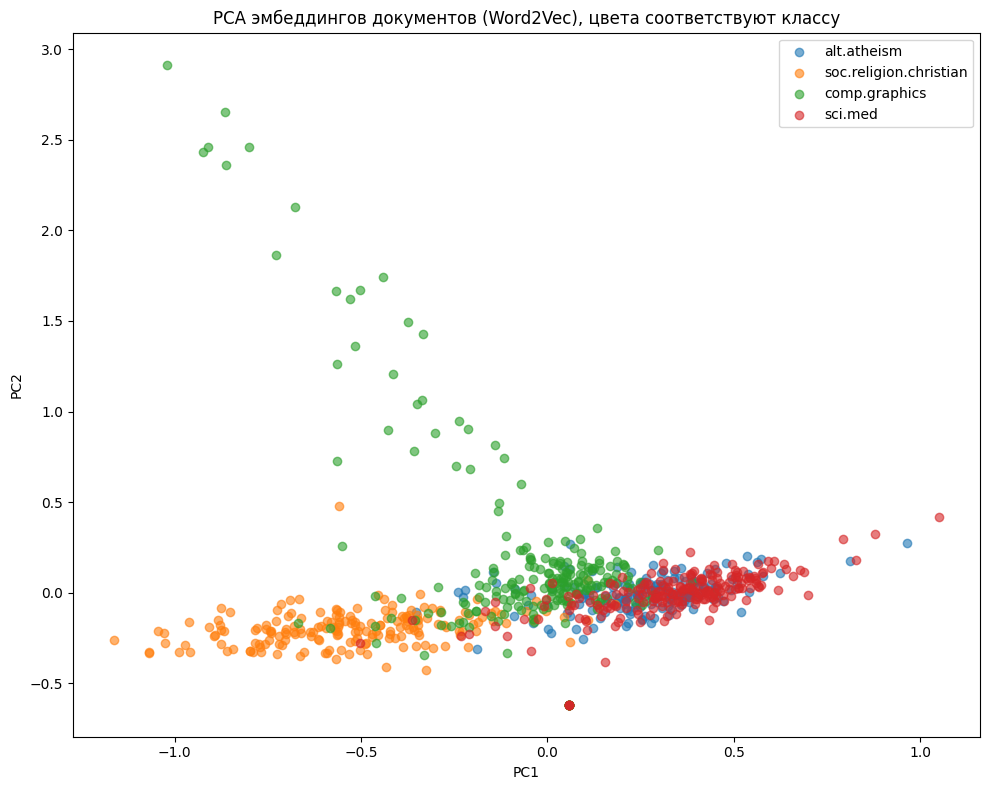

In [32]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [39]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# Подготовка данных
train_docs = X_train_processed[:800]
test_docs = X_test_processed[:50]

# Считаем Average Word2Vec эмбеддинги для обучающей выборки
print("Создание Average W2V эмбеддингов для обучающей выборки")
w2v_embeddings = np.array([get_phrase_embedding(doc, w2v_model) for doc in train_docs])
print(f"Форма W2V матрицы: {w2v_embeddings.shape}")

# Doc2Vec эмбеддинги
d2v_embeddings = np.array([d2v_model.dv[i] for i in range(len(train_docs))])
print(f"Форма D2V матрицы: {d2v_embeddings.shape}")

# Функция поиска ближайших соседей
def find_top_k(query_vec, embeddings_matrix, k=3):
    dists = cdist(query_vec.reshape(1, -1), embeddings_matrix, metric='cosine')[0]
    top_k_indices = np.argsort(dists)[:k]
    return [(idx, 1 - dists[idx]) for idx in top_k_indices]

# Выбираем запрос из теста
query_idx = 5
query_text = test_docs[query_idx]

print(f"ЗАПРОС (тестовый документ #{query_idx}):")
print(query_text[:300])

# Получаем векторы запроса
# Average W2V
query_w2v = get_phrase_embedding(query_text, w2v_model).reshape(1, -1)
# Doc2Vec (инференс для нового документа)
query_tokens = query_text.split()
query_d2v = d2v_model.infer_vector(query_tokens).reshape(1, -1)

# Ищем топ-3 похожих в обучающей выборке
print("\nРезультаты Average Word2Vec")
w2v_results = find_top_k(query_w2v, w2v_embeddings, k=3)
for rank, (doc_id, score) in enumerate(w2v_results, 1):
    print(f"\n#{rank} Документ #{doc_id} (сходство: {score:.4f})")
    print(f"Текст: {train_docs[doc_id][:200]}")

print("Результаты Doc2Vec")
d2v_results = find_top_k(query_d2v, d2v_embeddings, k=3)
for rank, (doc_id, score) in enumerate(d2v_results, 1):
    print(f"\n#{rank} Документ #{doc_id} (сходство: {score:.4f})")
    print(f"Текст: {train_docs[doc_id][:200]}")

Создание Average W2V эмбеддингов для обучающей выборки
Форма W2V матрицы: (800, 100)
Форма D2V матрицы: (800, 50)
ЗАПРОС (тестовый документ #5):
agree hard feeling believing grandgrand mother told elf dancing outside barn early morning preferred accept even statement provided truth life hard kent truly brilliant rebuttal apparently opinion ridicule suitable substitute reason youll find plenty company

Результаты Average Word2Vec

#1 Документ #525 (сходство: 0.9930)
Текст: agree hard feeling believing grandgrand mother told elf dancing outside barn early morning preferred accept even statement provided truth life hard cheer kent

#2 Документ #78 (сходство: 0.9864)
Текст: convinced religious fantasy time messiah rebel leader organisation jew built godhood purpose throwing yoke roman oppression moslem fanatic strap bomb back driving jewish embassy dying truth hint think

#3 Документ #110 (сходство: 0.9853)
Текст: sorry disappoint afraid friendship danger perhaps examine good friend unwill

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [34]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [35]:
print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.780  precision(macro)=0.781  recall(macro)=0.768
                        precision    recall  f1-score   support

           alt.atheism       0.78      0.48      0.59       107
soc.religion.christian       0.76      0.91      0.83       117
         comp.graphics       0.81      0.80      0.80       136
               sci.med       0.77      0.88      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.76       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.750  precision(macro)=0.745  recall(macro)=0.740
                        precision    recall  f1-score   support

           alt.atheism       0.66      0.47      0.55       107
soc.religion.christian       0.81      0.90      0.85       117
         comp.graphics       0.81      0.77      0.79       136
               sci.med    

In [ ]:
print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.682  precision(macro)=0.697  recall(macro)=0.672
                        precision    recall  f1-score   support

           alt.atheism       0.73      0.37      0.49       107
soc.religion.christian       0.60      0.90      0.72       117
         comp.graphics       0.76      0.60      0.67       136
               sci.med       0.70      0.82      0.76       140

              accuracy                           0.68       500
             macro avg       0.70      0.67      0.66       500
          weighted avg       0.70      0.68      0.67       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.746  precision(macro)=0.739  recall(macro)=0.741
                        precision    recall  f1-score   support

           alt.atheism       0.62      0.55      0.58       107
soc.religion.christian       0.79      0.90      0.84       117
         comp.graphics       0.82      0.76      0.79       136
               sci.med       0.73     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

Логистическая регрессия почти не улучшилась, потому что она линейная модель и уже хорошо работает с TF-IDF, где данные легко разделяются по словам. Word2Vec меняет представление текста на плотные векторы, где важны нелинейные связи, но линейная модель не умеет их использовать. RandomForest, наоборот, хорошо ловит такие нелинейные зависимости, поэтому на Word2Vec даёт заметный прирост

Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

In [44]:
from scipy.sparse import hstack

# Обычный BoW (1-gram)
bow = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
X_train_bow = bow.fit_transform(X_train_processed)
X_test_bow = bow.transform(X_test_processed)
print(f"BoW размерность: {X_train_bow.shape}")

# N-grams (1-2 граммы)
ngram = CountVectorizer(ngram_range=(1, 2), max_features=10000, min_df=2, max_df=0.95)
X_train_ngram = ngram.fit_transform(X_train_processed)
X_test_ngram = ngram.transform(X_test_processed)
print(f"N-grams размерность: {X_train_ngram.shape}")

# Комбинированные признаки (BoW + N-grams)
X_train_comb = hstack([X_train_bow, X_train_ngram])
X_test_comb = hstack([X_test_bow, X_test_ngram])
print(f"Комбинированные признаки размерность: {X_train_comb.shape}")

# W2V (среднее эмбеддингов слов)
X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in X_train_processed])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in X_test_processed])
print(f"W2V размерность: {X_train_w2v.shape}")

print("\nОбучение моделей...")

lr_bow = LogisticRegression(max_iter=500, random_state=42).fit(X_train_bow, y_train)
lr_ngram = LogisticRegression(max_iter=500, random_state=42).fit(X_train_ngram, y_train)
lr_comb = LogisticRegression(max_iter=500, random_state=42).fit(X_train_comb, y_train)
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)

print("Сравнение точности классификаторов")

models = [
    ("BoW (1-gram)", lr_bow, X_test_bow),
    ("N-grams (1-2)", lr_ngram, X_test_ngram),
    ("BoW + N-grams", lr_comb, X_test_comb),
    ("W2V (avg embeddings)", lr_w2v, X_test_w2v),
]

for name, model, X_test in models:
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<25} Accuracy: {acc:.4f}")

print(classification_report(y_test, lr_comb.predict(X_test_comb), 
                          target_names=categories, zero_division=0))

BoW размерность: (1000, 5000)
N-grams размерность: (1000, 10000)
Комбинированные признаки размерность: (1000, 15000)
W2V размерность: (1000, 100)

Обучение моделей...
Сравнение точности классификаторов
BoW (1-gram)              Accuracy: 0.7340
N-grams (1-2)             Accuracy: 0.7420
BoW + N-grams             Accuracy: 0.7400
W2V (avg embeddings)      Accuracy: 0.7500
                        precision    recall  f1-score   support

           alt.atheism       0.69      0.64      0.66       107
soc.religion.christian       0.68      0.85      0.76       117
         comp.graphics       0.78      0.67      0.72       136
               sci.med       0.80      0.79      0.80       140

              accuracy                           0.74       500
             macro avg       0.74      0.74      0.73       500
          weighted avg       0.74      0.74      0.74       500



Вывод: W2V (avg embeddings) неожиданно показал лучшую точность (0.7500), превзойдя статистические методы. N-grams (0.7420) улучшили результат обычного BoW (0.7340) за счет учета фраз. Комбинация признаков (BoW + N-grams) не дала прироста, что может указывать на избыточность или необходимость настройки регуляризации